In [1]:
import pandas as pd

df = pd.read_csv('../input/chennai-bus-route/route_detail.csv')

df.head()


,Unnamed: 0,route_id,stop_id,stop_name
0,0,1,1,THIRUVOTRIYUR
1,1,1,2,THIRUVOTRIYUR TEMPLE
2,2,1,3,THANGAL
3,3,1,4,ANNA NAGAR
4,4,1,5,ROYAPURAM P.S


# Data cleaning

In [2]:
# removing unwanted columns 
df = df.iloc[:,1:]
df.head()

,route_id,stop_id,stop_name
0,1,1,THIRUVOTRIYUR
1,1,2,THIRUVOTRIYUR TEMPLE
2,1,3,THANGAL
3,1,4,ANNA NAGAR
4,1,5,ROYAPURAM P.S


# Top 10 Stop which have high bus traffic

In [3]:
stat = df.groupby(by=["stop_name"])["route_id"].count().sort_values(ascending=False)
stat.iloc[:10]

stop_name
BROADWAY           138
M.G.R.CENTRAL      113
CONCORDE           105
SAIDAPET            95
THIRUMANGALAM       72
M.G.R.KOYAMBEDU     72
TAMBARAM            69
GUINDY R.S          59
AMBATTUR I.E.       58
P.OR & SONS         57
Name: route_id, dtype: int64

# Visualize data

* Found network graph will best suit for the usecase

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

**Visualizing Buses passing through a stop**

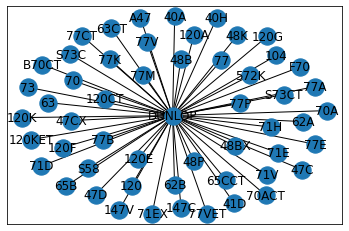

In [5]:
sample = df[df["stop_name"]=="DUNLOP"]
G = nx.from_pandas_edgelist(sample, "route_id", "stop_name")
nx.draw_networkx(G)
plt.show()

# Data manipulation to calculate next stop

In [6]:
df.head()
df["next_stop"] = df.groupby(by=["route_id"])["stop_name"].shift(-1)
df.loc[:50]

,route_id,stop_id,stop_name,next_stop
0,1,1,THIRUVOTRIYUR,THIRUVOTRIYUR TEMPLE
1,1,2,THIRUVOTRIYUR TEMPLE,THANGAL
2,1,3,THANGAL,ANNA NAGAR
3,1,4,ANNA NAGAR,ROYAPURAM P.S
4,1,5,ROYAPURAM P.S,CLIVE BATTERY
5,1,6,CLIVE BATTERY,PARRYS
6,1,7,PARRYS,M.G.R.CENTRAL
7,1,8,M.G.R.CENTRAL,P.OR & SONS
8,1,9,P.OR & SONS,WESLEY H.S
9,1,10,WESLEY H.S,Y.M.I.A


* Assigning next stop for last stop as route_id (Bus number) for easy visualization later

In [7]:
df.loc[df["next_stop"].isna(), "next_stop"] = df.loc[df["next_stop"].isna(), "route_id"]
df.loc[:50]

,route_id,stop_id,stop_name,next_stop
0,1,1,THIRUVOTRIYUR,THIRUVOTRIYUR TEMPLE
1,1,2,THIRUVOTRIYUR TEMPLE,THANGAL
2,1,3,THANGAL,ANNA NAGAR
3,1,4,ANNA NAGAR,ROYAPURAM P.S
4,1,5,ROYAPURAM P.S,CLIVE BATTERY
5,1,6,CLIVE BATTERY,PARRYS
6,1,7,PARRYS,M.G.R.CENTRAL
7,1,8,M.G.R.CENTRAL,P.OR & SONS
8,1,9,P.OR & SONS,WESLEY H.S
9,1,10,WESLEY H.S,Y.M.I.A


# Sample data creation - Dunlop stop

In [8]:
sample_routes = df[df["stop_name"]=="DUNLOP"]["route_id"]
sample = df[df["route_id"].isin(sample_routes)]
sample.head()

,route_id,stop_id,stop_name,next_stop
204,104,1,REDHILLS,AYURVEDHA ASHARAMAM
205,104,2,AYURVEDHA ASHARAMAM,KAVANGARAI
206,104,3,KAVANGARAI,SCREW FACTORY
207,104,4,SCREW FACTORY,SURAPEDU
208,104,5,SURAPEDU,KALLIKUPPAM


* **Except for base stop all other stop should be unique to route, So bus route can be visualized clearly without intersection between stops**

In [9]:
# sample["derived_next_stop"] = sample.apply(lambda row: row["next_stop"] if(row["next_stop"]=="DUNLOP") else row["route_id"]+row["next_stop"], axis=1)
# sample = sample.drop("derived_next_stop",axis=1)
sample.loc[~(sample["next_stop"]=="DUNLOP") & ~(sample["next_stop"]==sample["route_id"]),"derived_next_stop"] =  sample["route_id"]+ "-" +sample["next_stop"]
sample.loc[(sample["next_stop"]=="DUNLOP") | (sample["next_stop"]==sample["route_id"]),"derived_next_stop"] = sample["next_stop"]
sample.loc[~(sample["stop_name"]=="DUNLOP"),"derived_stop_name"] = sample["route_id"]+ "-" + sample["stop_name"]
sample.loc[sample["stop_name"]=="DUNLOP","derived_stop_name"] = sample["stop_name"]
sample.head()

/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1681: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = empty_value
/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1773: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


,route_id,stop_id,stop_name,next_stop,derived_next_stop,derived_stop_name
204,104,1,REDHILLS,AYURVEDHA ASHARAMAM,104-AYURVEDHA ASHARAMAM,104-REDHILLS
205,104,2,AYURVEDHA ASHARAMAM,KAVANGARAI,104-KAVANGARAI,104-AYURVEDHA ASHARAMAM
206,104,3,KAVANGARAI,SCREW FACTORY,104-SCREW FACTORY,104-KAVANGARAI
207,104,4,SCREW FACTORY,SURAPEDU,104-SURAPEDU,104-SCREW FACTORY
208,104,5,SURAPEDU,KALLIKUPPAM,104-KALLIKUPPAM,104-SURAPEDU


# Creating Graph

In [10]:
G = nx.from_pandas_edgelist(sample, "derived_stop_name", "derived_next_stop", create_using=nx.DiGraph())
print(nx.is_directed(G))

True



# coloring based on bus number

In [11]:
!pip install distinctipy

In [12]:
from distinctipy import distinctipy

routes = sample["route_id"].unique()
n=len(list(routes))
# print(list(route))

reserved_color = [(1,0,0),(0,1,0),(0,0,1),(0.8,0.6,0.3)]

# generate N visually distinct colours
colors = distinctipy.get_colors(n,reserved_color)
# print(colors)
route_color_map = { route: color for route, color in zip(routes,colors)}
# print(route_color_map)

# color edges based on route

In [13]:
edge_color = []
for u,v in G.edges():
    route_id = None
    u_list = u.split("-")
    v_list = v.split("-")
    if len(u_list) > 1:
        route_id = u_list[0]
    elif len(v_list) > 1:
        route_id = v_list[0]
    
    edge_color.append(route_color_map[route_id])
# print(edge_color)

# Color node based on stops

In [14]:
stops = sample["stop_name"].unique()
n=len(list(stops))

print(n)

reserved_color = [(1,0,0),(0,1,0),(0,0,1)] + edge_color

# generate N visually distinct colours
colors = distinctipy.get_colors(n,reserved_color)
# print(colors)
stop_color_map = { stop: color for stop, color in zip(stops,colors)}
# print(stop_color_map)

186


In [15]:
node_color =[]
root_node = None
labels = {}
for node in G:
    if node == "DUNLOP":
        # current stop
        root_node = node
        node_color.append((0,1,0)) #green
        labels[node] = node
    elif node in list(sample["route_id"]):
        node_color.append((1,0,0)) #red
        labels[node] = node
    else:
        labels[node] = sample.loc[sample["derived_stop_name"]== node,"stop_id"].values[0]
        node_color.append(stop_color_map[node.split("-")[1]]) #route wise color
# print(root_node)
# print(labels)
        

* use graphviz radical layout
* add these details in legend
* increse edge width

# Creating Legend for the graph

In [16]:
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Current Stop (DUNLOP)',markerfacecolor='g', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='Bus number',markerfacecolor='r', markersize=15),        
]
route_legend = [
    Line2D([0], [0], marker='d', color='w', label= bus_num,markerfacecolor=route_color_map[bus_num], markersize=15) for bus_num in route_color_map
]
stop_legend = [
    Line2D([0], [0], marker='o', color='w', label= stop,markerfacecolor=stop_color_map[stop], markersize=15) for stop in stop_color_map
]
legend_elements = legend_elements + route_legend + stop_legend

# Drawing Graph

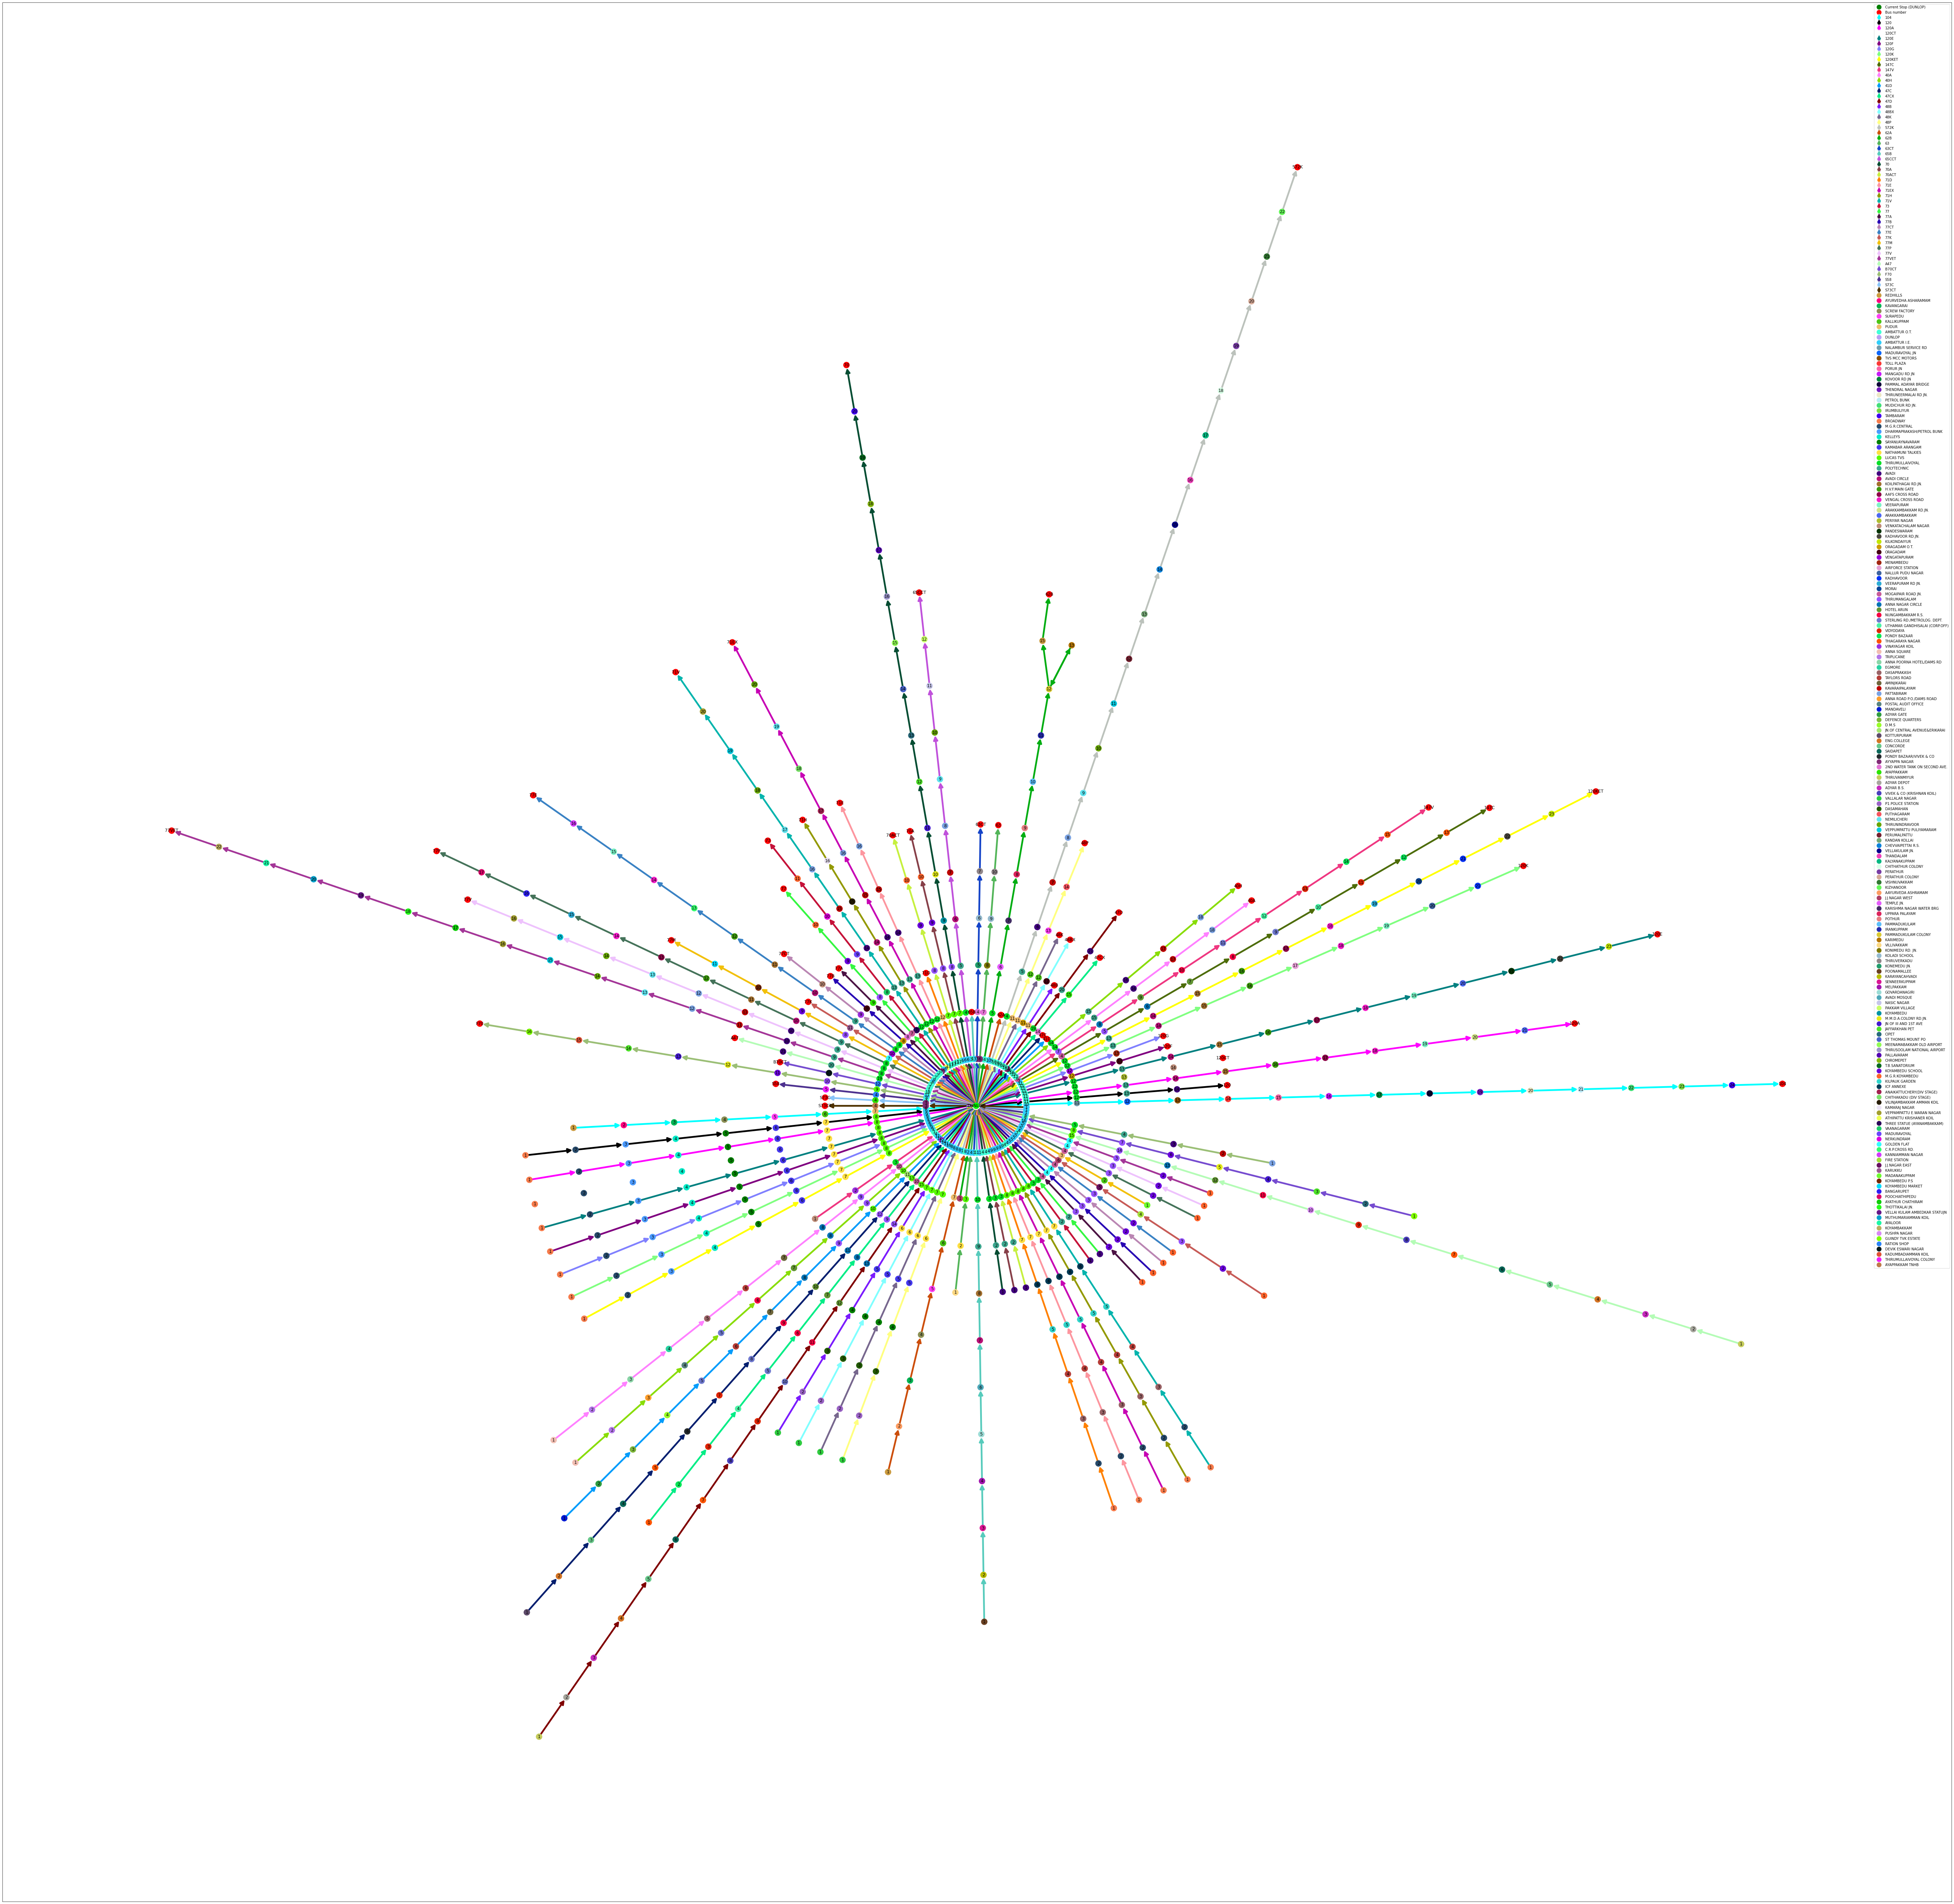

In [17]:
plt.figure(figsize=(100,100))
pos=nx.nx_pydot.graphviz_layout(G,prog="twopi",root=root_node)
nx.draw_networkx(G, pos=pos,edge_color=edge_color, node_color=node_color, arrows=True,
    arrowsize= 25, width=5, labels=labels)
plt.legend(handles=legend_elements, loc='upper right')
plt.savefig('routewise_map_from_dunlop.png')

# Future Enhancement
Instead of having stops unique to route, multi route (edge) should pass through same stop (node).

Need to explore ways to makes edges curve without interacting with each other 

More visually appealing and informative graph can be created 

# Original Draft can be found in below link
[chennai_bus_route_map_generation](https://www.kaggle.com/baarathsrinivasan/chennai-bus-route-map-generation)